In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:

df = pd.read_csv("iris_with_species.csv")


X = df.iloc[:, :-1]

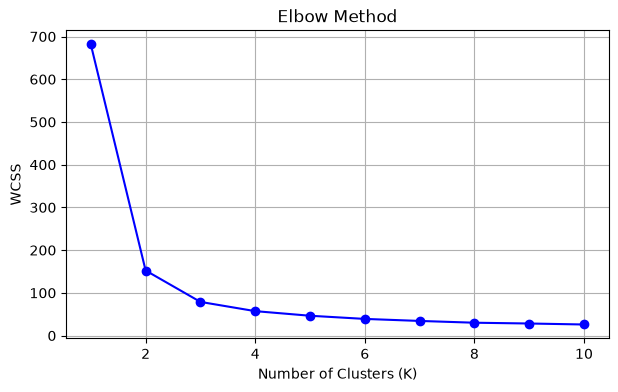

In [5]:

wcss = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    km.fit(X)
    wcss.append(km.inertia_)

# Elbow Method Graph
plt.figure(figsize=(7,4))
plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linestyle='-',
    color='blue'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1


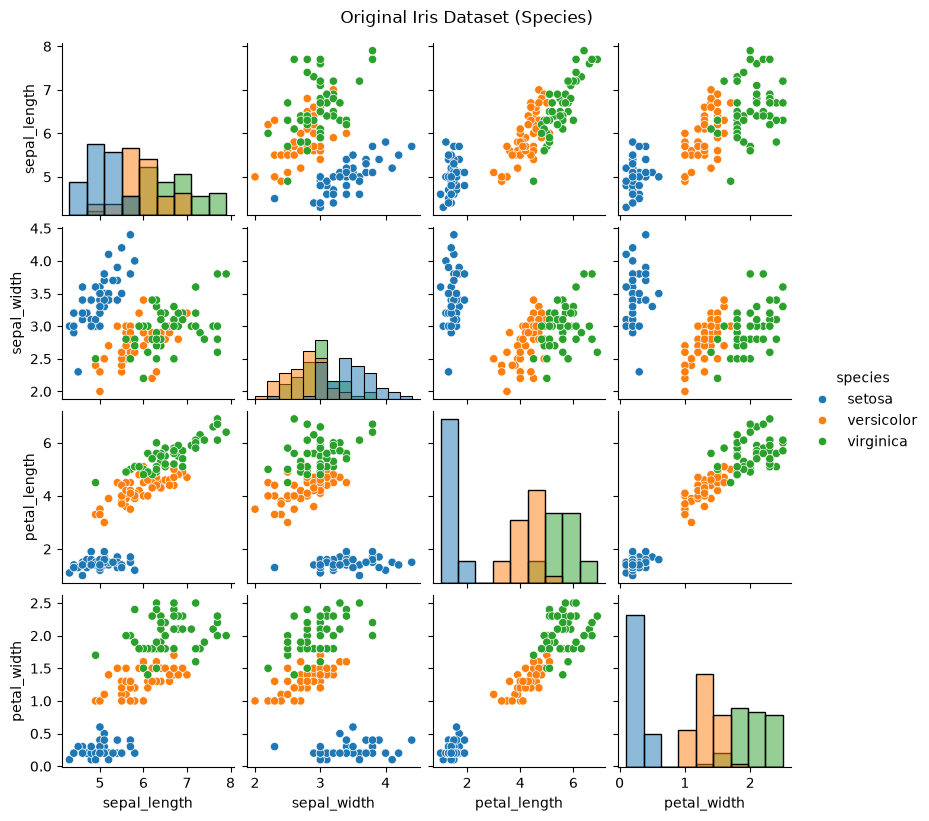

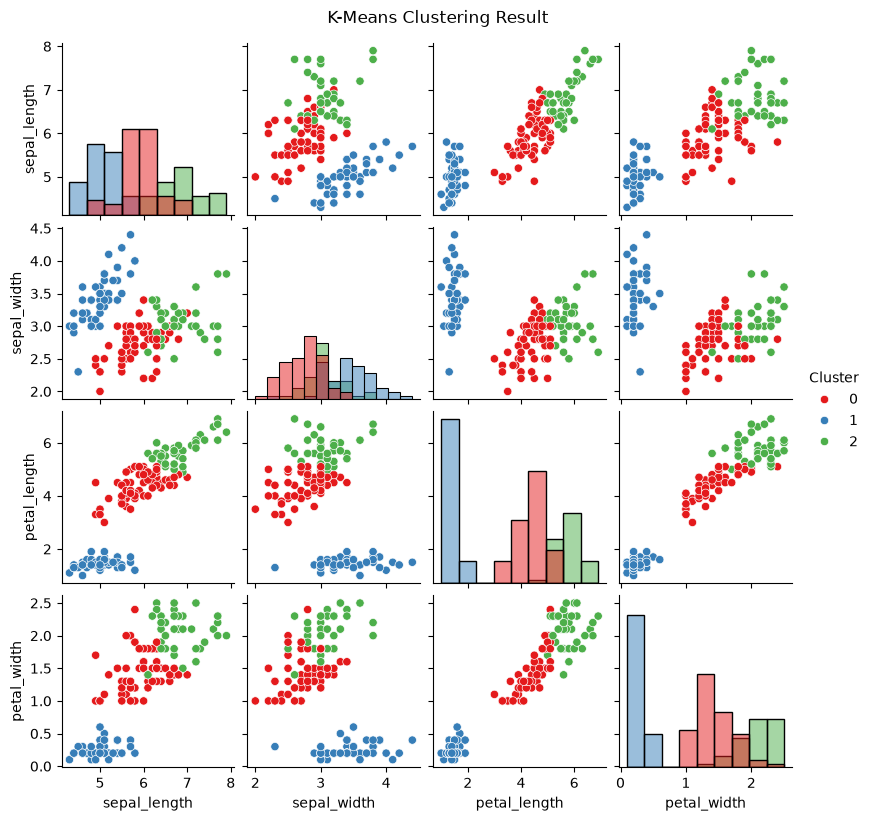

In [11]:

import seaborn as sns


df = pd.read_csv("iris_with_species.csv")


sns.pairplot(
    df,
    hue="species",
    diag_kind="hist",
    height=2
)

plt.suptitle("Original Iris Dataset (Species)", y=1.02)
plt.show()


X = df.iloc[:, :-1]  

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)


sns.pairplot(
    df,
    vars=["sepal_length",
          "sepal_width",
          "petal_length",
          "petal_width"],
    hue="Cluster",
    palette="Set1",
    diag_kind="hist",
    height=2
)

plt.suptitle("K-Means Clustering Result", y=1.02)
plt.show()

In [12]:
print(
    pd.crosstab(
        df["species"],
        df["Cluster"]
    )
)

Cluster      0   1   2
species               
setosa       0  50   0
versicolor  48   0   2
virginica   14   0  36
